In [1]:
from langgraph.graph import StateGraph
from langchain_cohere import ChatCohere
from typing import TypedDict, Literal
from rich import print

In [ ]:
llm = ChatCohere(
    cohere_api_key="YOUR_API_KEY"
)

In [3]:
class GraphState(TypedDict):
    """State for the routing workflow"""
    question: str
    intent: str
    answer: str
    final: str

In [4]:
technical_words = {"code", "python", "javascript", "java", "error", "bug", 
                   "function", "class", "api", "database", "sql", "debug",
                   "algorithm", "data structure", "framework", "library"}

In [5]:
def classify_intent_node(state: GraphState) -> dict:
    """
    Classify user intent based on keywords in the question.
    Returns 'technical' if technical keywords found, else 'general'
    """
    question_lower = state["question"].lower().strip()
    words_list = question_lower.split()
    
    # Check if any technical keywords are present
    is_technical = any(word in technical_words for word in words_list)
    
    # Also check for multi-word technical terms
    for tech_term in ["data structure", "machine learning", "deep learning", "neural network"]:
        if tech_term in question_lower:
            is_technical = True
            break
    
    intent = "technical" if is_technical else "general"
    
    print(f"[CLASSIFY] Question: '{state['question']}' → Intent: {intent}")
    
    return {
        **state,
        "intent": intent
    }

In [6]:
def technical_answer_node(state: GraphState) -> dict:
    """
    Generate a technical answer for code/programming-related questions
    """
    prompt = f"""You are an expert technical assistant specializing in programming, software engineering, and computer science.
 
Question: {state["question"]}
 
Provide a clear, detailed technical answer with:
1. Direct answer to the question
2. Code examples if relevant
3. Best practices or considerations
4. Related concepts or resources"""
    
    response = llm.invoke(prompt).content
    
    print(f"[TECHNICAL] Generated technical answer ({len(response)} chars)")
    
    return {
        **state,
        "answer": response
    }

In [7]:
def general_answer_node(state: GraphState) -> dict:
    """
    Generate a general answer for non-technical questions
    """
    prompt = f"""You are a helpful general knowledge assistant.
 
Question: {state["question"]}
 
Provide a clear, concise, and informative answer in a conversational tone."""
    
    response = llm.invoke(prompt).content
    
    print(f"[GENERAL] Generated general answer ({len(response)} chars)")
    
    return {
        **state,
        "answer": response
    }

In [8]:
def format_answer_node(state: GraphState) -> dict:
    """
    Format the final response with structured headers
    """
    formatted_response = f"""# Answer
 
{state["answer"]}
 
## Metadata
- **Type**: {state["intent"].upper()}
- **Original Question**: {state["question"]}"""
    
    print(f"[FORMAT] Final response formatted")
    
    return {
        **state,
        "final": formatted_response
    }

In [9]:
def router(state: GraphState) -> Literal["technical", "general"]:
    """
    Route to technical or general answer node based on classified intent
    """
    return state["intent"]

In [10]:
graph = StateGraph(GraphState)

graph.add_node("classify_intent", classify_intent_node)
graph.add_node("technical_answer", technical_answer_node)
graph.add_node("general_answer", general_answer_node)
graph.add_node("format_answer", format_answer_node)

In [12]:
graph.set_entry_point("classify_intent")
graph.add_conditional_edges(
    "classify_intent",
    router,
    {
        "technical": "technical_answer",
        "general": "general_answer"
    }
)
graph.add_edge("technical_answer", "format_answer")
graph.add_edge("general_answer", "format_answer")
graph.set_finish_point("format_answer")

In [13]:
app = graph.compile()

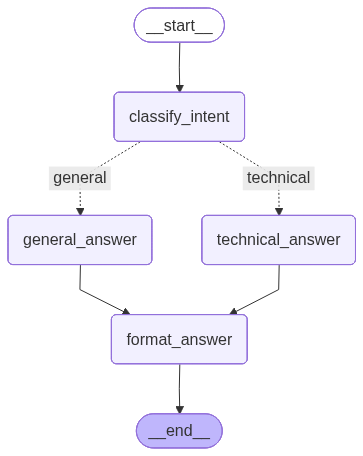

In [14]:
app

In [15]:
initial_state: GraphState = {
    "question": "How do I implement a binary search tree in Python?",
    "intent": "",
    "answer": "",
    "final": ""
}

result = app.invoke(initial_state)

[CLASSIFY] Question: 'How do I implement a binary search tree in Python?' → Intent: general

[GENERAL] Generated general answer (2579 chars)

[FORMAT] Final response formatted

In [16]:
print(result)

{
    'question': 'How do I implement a binary search tree in Python?',
    'intent': 'general',
    'answer': 'Implementing a binary search tree (BST) in Python is a great way to understand tree data structures 
and their operations. Here’s a simple and concise implementation to get you started:\n\n```python\nclass 
TreeNode:\n    def __init__(self, key):\n        self.key = key\n        self.left = None\n        self.right = 
None\n\nclass BinarySearchTree:\n    def __init__(self):\n        self.root = None\n\n    def insert(self, key):\n 
if self.root is None:\n            self.root = TreeNode(key)\n        else:\n            
self._insert_recursive(self.root, key)\n\n    def _insert_recursive(self, node, key):\n        if key < node.key:\n
if node.left is None:\n                node.left = TreeNode(key)\n            else:\n                
self._insert_recursive(node.left, key)\n        else:\n            if node.right is None:\n                
node.right = TreeNode(key)\n            else:\n                self._insert_recursive(node.right, key)\n\n    def 
search(self, key):\n        return self._search_recursive(self.root, key)\n\n    def _search_recursive(self, node, 
key):\n        if node is None or node.key == key:\n            return node is not None\n        if key < 
node.key:\n            return self._search_recursive(node.left, key)\n        return 
self._search_recursive(node.right, key)\n\n    def inorder_traversal(self):\n        result = []\n        
self._inorder_recursive(self.root, result)\n        return result\n\n    def _inorder_recursive(self, node, 
result):\n        if node:\n            self._inorder_recursive(node.left, result)\n            
result.append(node.key)\n            self._inorder_recursive(node.right, result)\n\n# Example usage:\nbst = 
BinarySearchTree()\nbst.insert(50)\nbst.insert(30)\nbst.insert(20)\nbst.insert(40)\nbst.insert(70)\nbst.insert(60)\
nbst.insert(80)\n\nprint("Inorder Traversal:", bst.inorder_traversal())  # Output: [20, 30, 40, 50, 60, 70, 
80]\nprint("Search 40:", bst.search(40))  # Output: True\nprint("Search 90:", bst.search(90))  # Output: 
False\n```\n\n### Explanation:\n1. **TreeNode Class**: Represents a node in the BST with a `key`, `left`, and 
`right` child.\n2. **BinarySearchTree Class**: Manages the BST with methods for insertion, search, and traversal.\n
- **Insert**: Adds a new key to the tree while maintaining the BST property.\n   - **Search**: Checks if a key 
exists in the tree.\n   - **Inorder Traversal**: Returns a sorted list of keys by traversing the tree in ascending 
order.\n\nThis implementation is recursive, but you can also implement iterative versions for insertion and search 
if preferred. Let me know if you\'d like help with that!',
    'final': '# Answer\n\nImplementing a binary search tree (BST) in Python is a great way to understand tree data 
structures and their operations. Here’s a simple and concise implementation to get you started:\n\n```python\nclass
TreeNode:\n    def __init__(self, key):\n        self.key = key\n        self.left = None\n        self.right = 
None\n\nclass BinarySearchTree:\n    def __init__(self):\n        self.root = None\n\n    def insert(self, key):\n 
if self.root is None:\n            self.root = TreeNode(key)\n        else:\n            
self._insert_recursive(self.root, key)\n\n    def _insert_recursive(self, node, key):\n        if key < node.key:\n
if node.left is None:\n                node.left = TreeNode(key)\n            else:\n                
self._insert_recursive(node.left, key)\n        else:\n            if node.right is None:\n                
node.right = TreeNode(key)\n            else:\n                self._insert_recursive(node.right, key)\n\n    def 
search(self, key):\n        return self._search_recursive(self.root, key)\n\n    def _search_recursive(self, node, 
key):\n        if node is None or node.key == key:\n            return node is not None\n        if key < 
node.key:\n   